# Heart Disease Prediction

**Description**


This project focuses on predicting the presence or absence of heart disease using patient medical data. The dataset contains 270 records with 14 attributes such as age, gender, chest pain type, blood pressure, cholesterol level, maximum heart rate, and other clinical indicators.

The target variable is Heart Disease, which has two classes:

*  Presence → Patient has heart disease

*  Absence → Patient does not have heart disease

This is a binary classification problem, where the goal is to classify patients into one of the two categories based on their medical features.

The model learns patterns from historical patient data and predicts whether a new patient is likely to have heart disease. After training the model, predictions are evaluated using Accuracy, Precision, and other classification metrics to measure how well the model performs.

Such predictive models can assist doctors in early diagnosis and decision-making by identifying high-risk patients.

**Purpose**

The purpose of the Heart Disease Prediction model is to identify whether a patient is at risk of having heart disease based on medical and clinical data.

This model helps in:

* Early detection of heart disease

* Supporting doctors in medical decision-making

* Reducing manual analysis of patient reports

**Libraries Used**

* Pandas: Used for loading, reading, and manipulating the dataset.

* NumPy: Used for numerical operations and handling arrays.

* Matplotlib: Used for basic data visualization such as graphs and plots.

* Seaborn: Used for advanced and statistical data visualization.


Scikit-learn (sklearn): Used for building machine learning models, splitting the dataset, making predictions, and evaluating model performance using metrics such as accuracy and precision

**Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score

**Load Dataset**

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Heart_Disease_Prediction.csv')
print(df.head())

    Age  Sex  Chest pain type     BP  Cholesterol  FBS over 120  EKG results  \
0  70.0  1.0              4.0  130.0        322.0           0.0          2.0   
1  67.0  0.0              3.0  115.0          NaN           0.0          2.0   
2  57.0  1.0              2.0  124.0        261.0           0.0          0.0   
3  64.0  1.0              4.0  128.0        263.0           0.0          0.0   
4  74.0  0.0              2.0    NaN        269.0           0.0          2.0   

   Max HR  Exercise angina  ST depression  Slope of ST  \
0   109.0              0.0            2.4          2.0   
1     NaN              0.0            1.6          2.0   
2   141.0              0.0            0.3          1.0   
3   105.0              1.0            0.2          2.0   
4   121.0              1.0            0.2          1.0   

   Number of vessels fluro  Thallium Heart Disease  
0                      3.0       3.0      Presence  
1                      0.0       7.0       Absence  
2          

**Check missing values**

In [ ]:
df.isnull().sum()

,0
Age,3
Sex,1
Chest pain type,2
BP,7
Cholesterol,5
FBS over 120,1
EKG results,1
Max HR,6
Exercise angina,2
ST depression,0


**Handling Missing Values**

In [ ]:
df.fillna(df.mean(numeric_only=True), inplace=True)
df['Heart Disease'].fillna(df['Heart Disease'].mode()[0], inplace=True)

/tmp/ipykernel_1850/3636218427.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Heart Disease'].fillna(df['Heart Disease'].mode()[0], inplace=True)


In [ ]:
df.isnull().sum()

,0
Age,0
Sex,0
Chest pain type,0
BP,0
Cholesterol,0
FBS over 120,0
EKG results,0
Max HR,0
Exercise angina,0
ST depression,0


**Convert Target**

In [ ]:
df['Heart Disease'] = df['Heart Disease'].map({'Presence':1, 'Absence':0})

**Unique**

In [ ]:
df['Heart Disease'].unique()

array([1, 0])

**Sort values**

In [ ]:
df_sorted = df.sort_values('Age')
print(df_sorted)

      Age  Sex  Chest pain type          BP  Cholesterol  FBS over 120  \
214  29.0  1.0              2.0  130.000000        204.0           0.0   
174  34.0  1.0              1.0  118.000000        182.0           0.0   
138  34.0  0.0              2.0  118.000000        210.0           0.0   
224  35.0  0.0              4.0  138.000000        183.0           0.0   
193  35.0  1.0              4.0  126.000000        282.0           0.0   
..    ...  ...              ...         ...          ...           ...   
255  71.0  0.0              2.0  160.000000        302.0           0.0   
29   71.0  0.0              3.0  110.000000        265.0           1.0   
4    74.0  0.0              2.0  131.448669        269.0           0.0   
73   76.0  0.0              3.0  140.000000        197.0           0.0   
199  77.0  1.0              4.0  125.000000        304.0           0.0   

     EKG results  Max HR  Exercise angina  ST depression  Slope of ST  \
214          2.0   202.0              

**Grouping by Heart Disease**

In [ ]:
df.groupby('Heart Disease').size()

,0
Heart Disease,
0,151
1,119


**Data Analysing**

In [ ]:
df.shape
df.dtypes
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    float64
 1   Sex                      270 non-null    float64
 2   Chest pain type          270 non-null    float64
 3   BP                       270 non-null    float64
 4   Cholesterol              270 non-null    float64
 5   FBS over 120             270 non-null    float64
 6   EKG results              270 non-null    float64
 7   Max HR                   270 non-null    float64
 8   Exercise angina          270 non-null    float64
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    float64
 11  Number of vessels fluro  270 non-null    float64
 12  Thallium                 270 non-null    float64
 13  Heart Disease            270 non-null    int64  
dtypes: float64(13), int64(1)
m

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.00000,270.000000,270.000000,270.000000
mean,54.314607,0.676580,3.167910,131.448669,248.950943,0.148699,1.026022,149.537879,0.328358,1.05000,1.58209,0.659176,4.687732,0.440741
std,9.038450,0.467781,0.947397,17.695804,47.469746,0.355791,0.995936,22.783907,0.468742,1.14521,0.61334,0.936626,1.935550,0.497398
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.00000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,214.250000,0.000000,0.000000,133.250000,0.000000,0.00000,1.00000,0.000000,3.000000,0.000000
50%,54.657303,1.000000,3.000000,130.000000,246.000000,0.000000,2.000000,152.000000,0.000000,0.80000,2.00000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,276.750000,0.000000,2.000000,165.000000,1.000000,1.60000,2.00000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,417.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.00000,3.000000,7.000000,1.000000


**Count Plot**

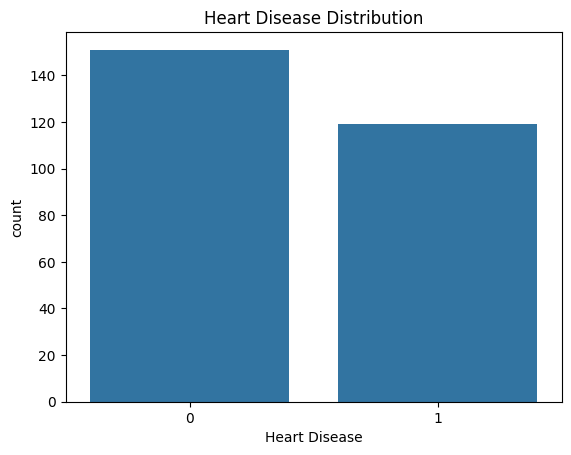

In [ ]:
sns.countplot(x='Heart Disease', data=df)
plt.title("Heart Disease Distribution")
plt.show()

**Correlation Heatmap**

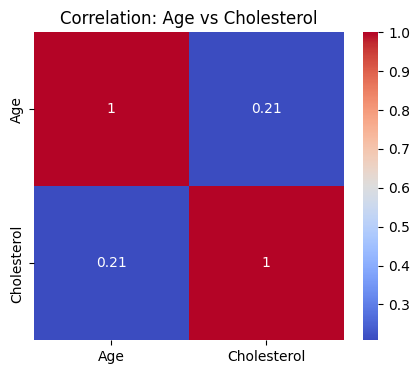

In [ ]:
cols = ['Age', 'Cholesterol']

plt.figure(figsize=(5,4))
sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation: Age vs Cholesterol")
plt.show()

**Histogram**

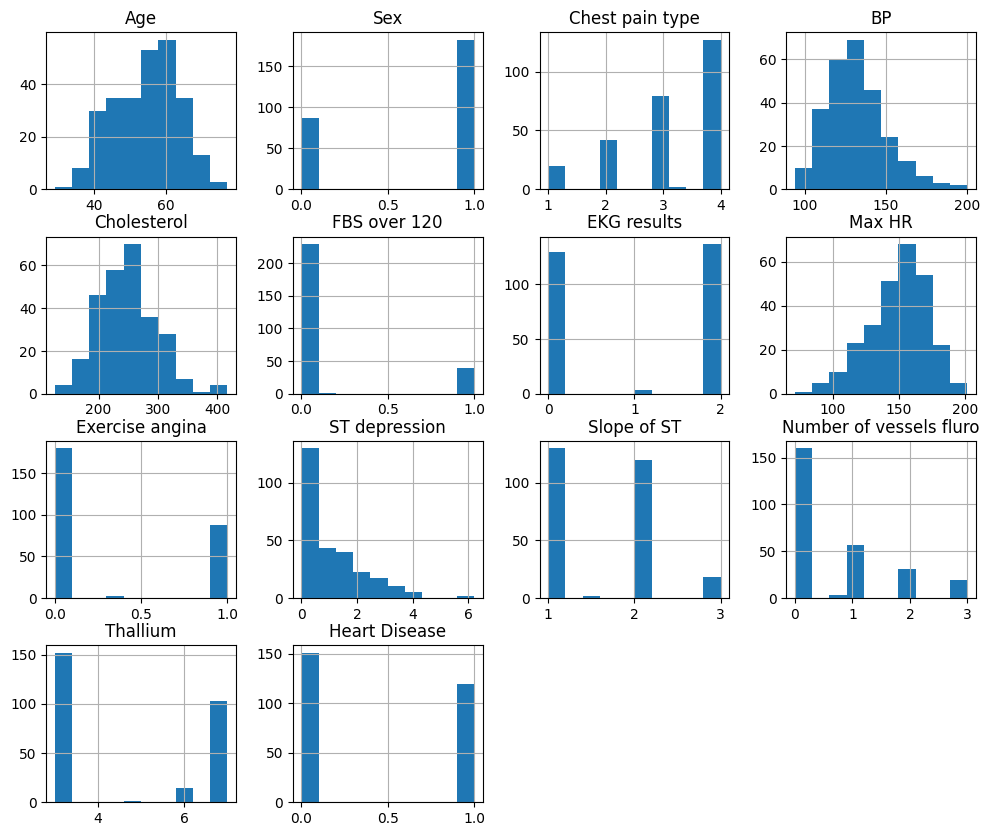

In [ ]:
df.hist(figsize=(12,10))
plt.show()

**Boxplot**

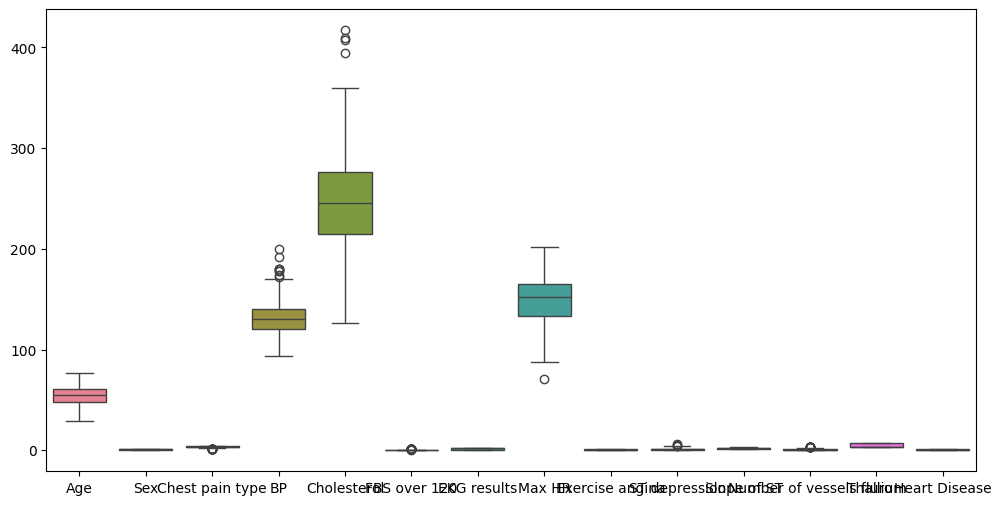

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.show()

**Feature-Target Separation**

In [ ]:
X = df.drop('Heart Disease', axis=1)
y = df['Heart Disease']

**Train-Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Feature Scaling**

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**Model Training (Logistic Regression ✅)**

In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

**Prediction**

In [ ]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

**Accuracy**

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8703703703703703


**Confusion Matrix**

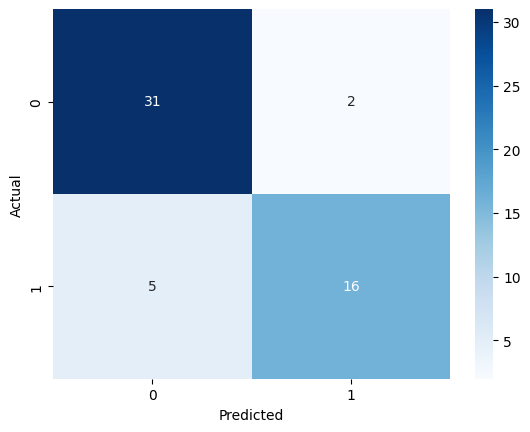

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**ROC Curve**

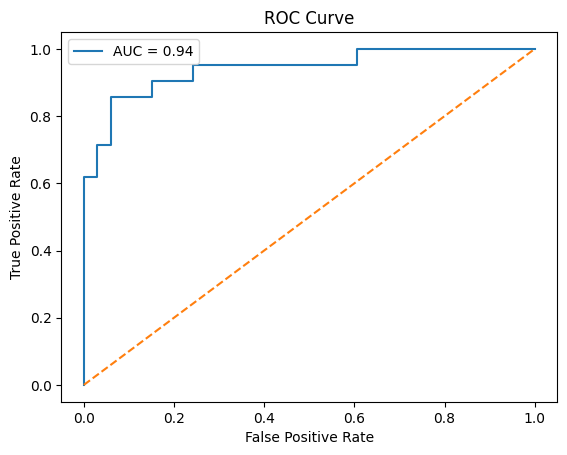

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

**Feature Importance (Model Coefficients Analysis)**

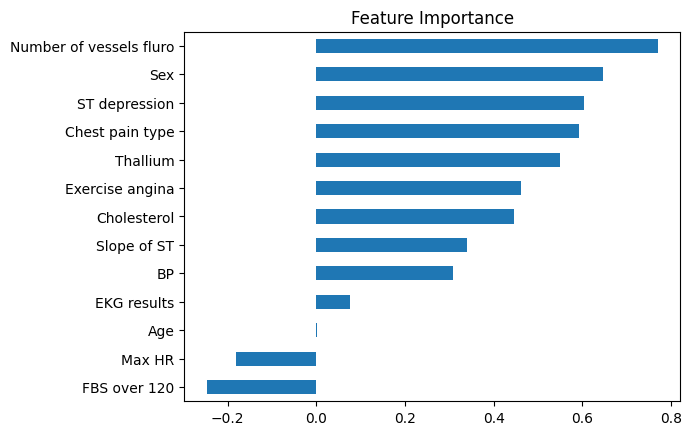

In [ ]:
importance = pd.Series(model.coef_[0], index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")

plt.show()